# Graph RAG: 관계를 검색해 근거 답변 만들기

**Graph RAG(Graph Retrieval-Augmented Generation)** 는 Graph DB에 명시적으로 저장된 노드·관계·경로를 검색하고, 그 결과를 LLM의 답변 근거로 사용하는 RAG 방식이다.

문서 조각의 의미 유사도만으로는 여러 단계를 거치는 관계를 정확히 찾기 어렵고, LLM의 기억만으로 답하면 근거를 확인하기 어렵기 때문에 필요하다.

Graph RAG는 `민지가 소속된 기관에서 제공하는 강좌는 무엇인가?`처럼 **누가 무엇과 어떻게 연결되는가**를 따라가야 하는 질문에 적합하다. <br>
이 질문은 `민지 → 소속 기관 → 제공 강좌`라는 여러 단계의 경로를 조회해야 답할 수 있다. 반대로 표현이 비슷한 문서 내용을 찾는 질문에는 Vector RAG가 더 적합할 수 있다.

앞 Neo4j 노트북에서는 사람·기관·강좌를 노드로, `WORKS_AT`·`OFFERS` 같은 연결을 관계로 저장했다. 이 노트북에서는 그 그래프를 새로 구축하지 않고, 이미 저장된 관계를 **자연어 질문 → Cypher 생성 → Neo4j 조회 → 그래프 문맥 → LLM 답변** 순서로 활용한다.

## Knowledge Graph와 트리플

**Graph DB**는 노드와 관계를 저장하고 경로를 조회하는 데이터베이스 기술이고, **Knowledge Graph**는 사람·기관·강좌 같은 현실의 대상과 그 의미 있는 관계를 그래프로 표현한 지식 구조이다. 앞 노트북에서 이 Knowledge Graph를 Neo4j에 저장했으며, 여기서는 저장된 사실을 검색한다.

Knowledge Graph의 사실 하나는 보통 **트리플(triple)** 로 읽는다.

```text
(:Person {name: '민지'})-[:WORKS_AT]->(:Organization {name: 'SKN'})
└──── 주어 노드 ────┘  └─ 관계 ─┘  └──────── 목적어 노드 ────────┘
```

`민지는 SKN에서 일한다`라는 한 사실을 두 노드와 방향 있는 관계로 표현한 것이다. `Person`, `Organization`은 노드 종류를 구분하는 **label**이고, `name`은 노드의 **property**이다. 여러 트리플을 연결하면 `민지 → SKN → RAG 강좌`처럼 한 단계보다 긴 질문도 경로 조회로 풀 수 있다. 다음 그림에서는 이 관계 경로가 Cypher 조회 결과를 거쳐 LLM의 답변 근거가 되는 전체 흐름을 확인한다.

Neo4j의 property graph 개념은 [Neo4j Graph database concepts 공식 문서](https://neo4j.com/docs/getting-started/appendix/graphdb-concepts/)에서 확인할 수 있다.

## Graph RAG 전체 흐름

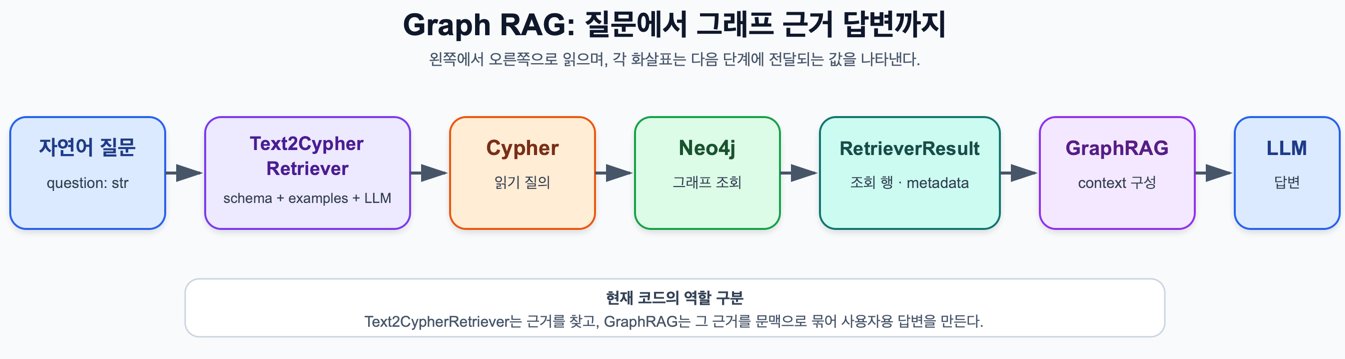

 `Text2CypherRetriever`는 자연어 질문과 스키마·예시를 사용해 Cypher를 만들고, Neo4j의 조회 행을 `RetrieverResult`로 반환한다.

`GraphRAG`는 그 조회 행을 **context(답변 근거로 넣는 문맥)** 로 묶어 LLM에 전달한다.

아래 코드에서는 하나의 `llm` 객체가 Cypher 생성과 최종 답변 생성에 모두 사용된다.

 [Neo4j GraphRAG Python 공식 가이드](https://neo4j.com/docs/neo4j-graphrag-python/current/user_guide_rag.html)
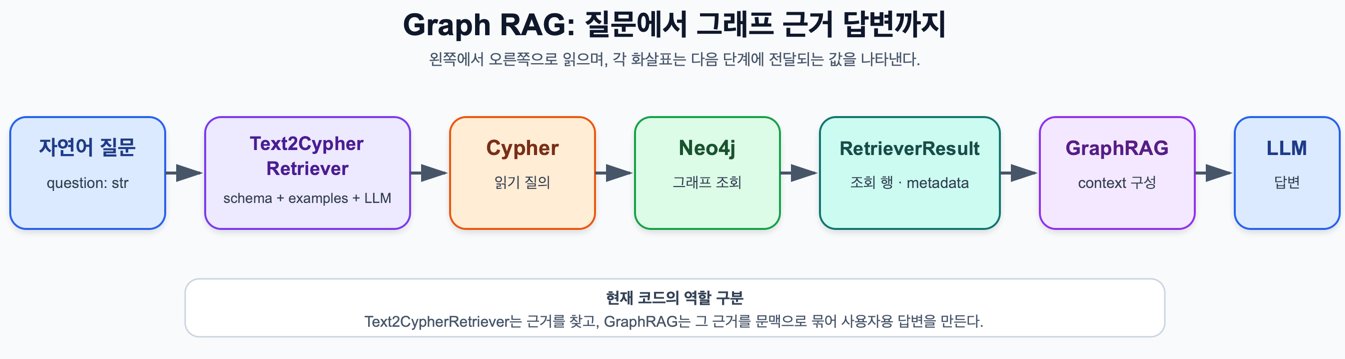

## Vector RAG와 Graph RAG의 경계

두 방식은 모두 외부 지식을 검색하지만 **무엇을 근거로 찾는지**가 다르다.

| 구분 | Vector RAG | Graph RAG |
|---|---|---|
| 검색 대상 | 문서 chunk | 노드·관계·경로 |
| 검색 기준 | embedding vector의 의미 유사도 | 관계 유형과 연결 방향을 표현한 그래프 질의 |
| 검색 결과 | 유사한 `Document` 목록 | Neo4j 조회 행을 담은 `RetrieverResult` |
| 잘 맞는 질문 | 표현은 달라도 내용이 비슷한 문서 찾기 | 소속·영향·경로처럼 연결을 따라가야 하는 질문 |

Graph DB를 한 번 조회했다고 바로 Graph RAG가 되는 것은 아니다. **조회 결과를 LLM의 문맥에 넣어 답변 생성까지 연결할 때** Graph RAG 파이프라인이 완성된다.

문서의 서술 내용이 핵심이면 Vector RAG를, 명시된 관계와 여러 단계 연결이 핵심이면 Graph RAG를 우선한다. 두 근거가 모두 필요하면 뒤의 Hybrid RAG처럼 함께 사용할 수 있다.

## 패키지와 실행 준비

`neo4j-graphrag`는 Neo4j 검색 결과를 LLM과 연결하는 공식 Graph RAG 패키지이다. 설치 문자열의 `[openai]`는 OpenAI 연동에 필요한 추가 의존성까지 함께 설치한다.

이 패키지는 내부에서 공식 `neo4j` Python driver를 사용하며, `python-dotenv`는 접속 정보와 API key를 `.env`에서 읽을 때 사용한다.

neo4j-genai`는 유지보수되지 않으므로 현재는 `neo4j-graphrag`를 사용한다.

 [Neo4j GraphRAG Python 공식 가이드](https://neo4j.com/docs/neo4j-graphrag-python/current/user_guide_rag.html)

In [2]:
%pip install -U neo4j-graphrag[openai] python-dotenv

   ---------------------------------------- 0.0/948.6 kB ? eta -:--:--
   ---------------------------------------- 948.6/948.6 kB 22.1 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [json-repair]
   ---------- ----------------------------- 1/4 [json-repair]
   ---------- ----------------------------- 1/4 [json-repair]
   ---------- ----------------------------- 1/4 [json-repair]
  Attempting uninstall: openai
   ---------- ----------------------------- 1/4 [json-repair]
    Found existing installation: openai 2.52.0
   ---------- ----------------------------- 1/4 [json-repair]
   -------------------- ------------------- 2/4 [openai]
   -------------------- ------------------- 2/4 [openai]
   -------------------- ------------------- 2/4 [openai]
   -------------------- ------------------- 2/4 [openai]
   -------------------- ------------------- 2/4 [openai]
    Uninstalling openai-2.52.0:
   -------------------- ------------------- 2/4 [openai]
      Successfully uninsta

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-openai 1.4.3 requires openai<3.0.0,>=2.45.0, but you have openai 1.109.1 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\playdata2\miniforge3\envs\llm_env\python.exe -m pip install --upgrade pip


## 환경 변수와 실행 객체 준비하기

`load_dotenv()`는 `.env`의 값을 현재 Python 프로세스의 환경 변수에 추가한다. 이어지는 코드는 DB 이름과 Chat Model 이름처럼 공개해도 되는 설정만 출력하며 URI·비밀번호·API key는 출력하지 않는다.

`GraphDatabase`는 Python에서 Neo4j로 Cypher를 보내는 driver를 만든다. `OpenAILLM`은 OpenAI Chat Model을 Neo4j GraphRAG가 사용할 수 있는 형식으로 감싼다.

검색과 생성의 역할도 여기서 구분한다. `Text2CypherRetriever`는 **질문을 Cypher와 조회 결과로 바꾸고**, `GraphRAG`는 **그 조회 결과를 문맥으로 넣어 최종 답변을 만든다**. 이 셀에서는 import와 설정만 수행하므로 아직 외부 요청이 발생하지 않는다.

In [3]:
import os

from dotenv import load_dotenv
from neo4j import GraphDatabase
from neo4j_graphrag.generation import GraphRAG
from neo4j_graphrag.llm import OpenAILLM
from neo4j_graphrag.retrievers import Text2CypherRetriever

load_dotenv()

neo4j_database = os.getenv('NEO4J_DATABASE', 'neo4j')
chat_model = os.getenv('OPENAI_CHAT_MODEL', 'gpt-5.6-luna')

## Neo4j driver와 LLM 준비하기

Graph RAG에는 서로 다른 두 실행 객체가 필요하다. `driver`는 생성된 Cypher를 Neo4j에 보내고 조회 행을 받으며, `llm`은 처음에는 질문을 Cypher로 바꾸고 마지막에는 검색 문맥을 자연어 답변으로 바꾼다.

이 셀의 `verify_connectivity()`부터 실제 Neo4j 연결이 발생한다. `OpenAILLM` 객체를 만드는 것만으로는 답변을 요청하지 않으며, 실제 OpenAI 호출은 뒤의 `search()`에서 시작된다.

같은 LLM 객체를 두 단계에 재사용할 수 있지만, 실서비스에서는 Cypher 생성용 모델과 답변 생성용 모델을 분리해 비용과 정확도를 조절할 수 있다.

In [4]:
required_settings = {
    'NEO4J_URI': os.getenv('NEO4J_URI'),
    'NEO4J_USERNAME': os.getenv('NEO4J_USERNAME'),
    'NEO4J_PASSWORD': os.getenv('NEO4J_PASSWORD'),
    'OPENAI_API_KEY': os.getenv('OPENAI_API_KEY'),
}

# 드라이버 생성
driver = GraphDatabase.driver(
    required_settings['NEO4J_URI'],
    auth=(
        required_settings['NEO4J_USERNAME'],
        required_settings['NEO4J_PASSWORD']
    ),
)

driver.verify_connectivity()

# LLM 객체 생성
llm = OpenAILLM(model_name=chat_model)

print("드라이버 및 LLM 객체 준비 완료")

드라이버 및 LLM 객체 준비 완료


## LLM에 그래프 구조와 Cypher 작성 예시 알려 주기

`neo4j_schema`는 LLM이 Cypher를 만들 때 참고하는 **그래프 구조 설명 문자열**이다. Neo4j에서 직접 실행하는 Cypher가 아니며, 실제 DB에 어떤 노드·속성·관계가 있는지 LLM에 알려 주는 설계도 역할을 한다.

### 노드 속성 읽기

노드 속성은 `Label {property: TYPE}` 형식으로 읽는다.

- `Person {name: STRING}`: `Person` 종류의 노드는 문자열 `name` 속성을 가진다.
- `Organization {name: STRING}`: `Organization` 종류의 노드는 문자열 `name` 속성을 가진다.
- `Course {title: STRING}`: `Course` 종류의 노드는 문자열 `title` 속성을 가진다.

### 관계 패턴 읽기

관계는 `(출발 노드)-[:관계 종류]->(도착 노드)` 형식으로 읽는다.

- `(:Person)`: `Person` 라벨을 가진 노드이다.
- `[:WORKS_AT]`: `WORKS_AT`이라는 관계 종류이다.
- `->`: 관계가 왼쪽 노드에서 오른쪽 노드로 향한다는 뜻이다.
- `(:Person)-[:WORKS_AT]->(:Organization)`: 사람이 기관에 소속된다.
- `(:Organization)-[:OFFERS]->(:Course)`: 기관이 강좌를 제공한다.
- `(:Person)-[:TEACHES]->(:Course)`: 사람이 강좌를 가르친다.

`examples`는 자연어 질문과 완성된 Cypher를 짝지은 참고 예시이다. LLM은 `neo4j_schema`에서 사용할 수 있는 구조를 확인하고, `examples`에서 `MATCH`와 `RETURN` 작성 방식을 참고한다. 두 값은 뒤의 `Text2CypherRetriever`에 전달되며 모델을 다시 학습시키지는 않는다.

In [19]:
neo4j_schema = """
Node properties:
Person {name: STRING}
Organization {name: STRING}
Course {title: STRING}

The relationships:
(:Person)-[:WORKS_AT]->(:Organization)
(:Organization)-[:OFFERS]->(:Course)
(:Person)-[:TEACHERS]->(:Course)
"""

# examples: 자연어 질문과 Cypher 쌍을 제공하는 few-shot 예시이다.
examples = [
    "USER INPUT: 'RAG 강좌를 담당하는 사람은 누구인가?' "
    "QUERY: MATCH (p:Person)-[:TEACHERS]->(c:Course {title: 'RAG'}) RETURN p.name AS instructor",

    "USER INPUT: '민지가 소속된 기관은 어디인가?' "
    "QUERY: MATCH (p:Person {name: '민지'})-[:WORKS_AT]->(o:Organization) RETURN o.name AS organization",

    "USER INPUT: 'SKN에 소속된 사람은 누가 있는가?'"
    "QUERY: MATCH (p:Person)-[:WORKS_AT]->(o:Organization {name: 'SKN'}) RETURN p.name AS person"
]


## `Text2CypherRetriever`로 검색 단계 구성하기

`Retriever`는 질문에 답할 **근거를 찾아 반환하는 검색 객체**이다. `Text2CypherRetriever`는 embedding 유사도를 계산하는 대신 LLM이 만든 Cypher로 Knowledge Graph를 조회한다.

처리 흐름은 다음과 같다.

**자연어 질문(`str`) → LLM의 Cypher 생성 → Neo4j 실행 → `RetrieverResult`**

생성자에는 앞에서 만든 `driver`, `llm`, `neo4j_schema`, `examples`, `neo4j_database`를 연결한다. 각 인자가 어느 단계에 쓰이는지는 코드 가까이의 주석에서 확인한다. 이 객체의 출력은 사용자용 답변이 아니라 다음 생성 단계에 전달할 조회 근거이다.

In [20]:
# 자연어 -> llm-> Cypher 변환(스키마,예시 참고)
# -> 해당 Cypher를 이용해서 Graph DB(Neo4j)에서 조회
# -> 조회 결과(RetrieverResult) 반환
graph_retriever = Text2CypherRetriever(
    llm=llm,
    neo4j_schema=neo4j_schema, # Graph DB Schema(구조)
    examples=examples, # Cypher 예시
    driver=driver, # DB 연결
    neo4j_database=neo4j_database # DB 이름
)

print(type(graph_retriever).__name__)

Text2CypherRetriever


## 자연어 질문을 그래프에서 검색하기

`search(query_text=...)`를 호출하면 OpenAI와 Neo4j 요청이 실제로 발생한다. LLM은 스키마와 예시를 참고해 Cypher를 만들고, Retriever는 읽기 질의인지 확인한 뒤 Neo4j에서 실행한다.

반환되는 `RetrieverResult`는 다음 구조로 읽는다.

```text
RetrieverResult
├─ items: 조회 행마다 만든 RetrieverResultItem 목록
│  ├─ content: 최종 LLM에 전달할 조회 행 문자열
│  └─ metadata: 해당 행의 부가 정보
└─ metadata: 생성된 Cypher처럼 검색 전체의 부가 정보
```

이 셀에서는 `items`의 내용과 `metadata['cypher']`를 함께 출력한다. 생성된 질의가 의도한 관계를 따라갔는지, 조회 행이 질문에 답할 근거인지 먼저 확인한 뒤 생성 단계로 넘어간다.

In [21]:
question = 'SKN에 소속된 사람은 누가 있는가?'

# Text2CypherRetriever를 이용해서 검색
# -> RetrieverResult 반환
retrieval_result = graph_retriever.search(query_text=question)

# retrieval_result.items: list[RetrieverResultItem]
# == Neo4j에서 조회된 각 행의 묶음
print("검색된 항목 수:", len(retrieval_result.items))
print("검색된 항목:", retrieval_result.items)

for index, item in enumerate(retrieval_result.items, start=1):
    print(f'[{index}] content:', item.content)

    # item.metadata는 항목별 부가 정보 dict 또는 None이며 현재 저장 출력에서는 두 항목 모두 None이다.
    print(f'[{index}] metadata:', item.metadata)

# retrieval_result.metadata는 검색 전체 정보 dict이며 cypher와 __retriever 같은 key를 담는다.
# items의 각 행 정보와 전체 검색 정보를 분리하면 답변 근거와 생성 질의를 따로 점검할 수 있다.
print('검색 metadata:', retrieval_result.metadata)

검색된 항목 수: 2
검색된 항목: [RetrieverResultItem(content="<Record person='민지'>", metadata=None), RetrieverResultItem(content="<Record person='현우'>", metadata=None)]
[1] content: <Record person='민지'>
[1] metadata: None
[2] content: <Record person='현우'>
[2] metadata: None
검색 metadata: {'cypher': "MATCH (p:Person)-[:WORKS_AT]->(o:Organization {name: 'SKN'}) RETURN p.name AS person", '__retriever': 'Text2CypherRetriever'}


## `GraphRAG`로 근거 있는 답변 생성하기

`Text2CypherRetriever.search()`는 검색 근거까지만 반환한다. `GraphRAG.search()`는 같은 Retriever를 호출하고, 조회 행의 `content`를 문맥으로 묶어 LLM의 최종 답변까지 생성한다.

| 호출 | 반환되는 핵심 값 | 확인 목적 |
|---|---|---|
| `graph_retriever.search()` | Cypher와 Neo4j 조회 행 | 검색이 올바른지 확인 |
| `graph_rag.search()` | 조회 근거와 사용자용 답변 | 답변이 근거를 반영했는지 확인 |

`return_context=True`를 사용하면 최종 결과에 실제 `RetrieverResult`도 남는다. 따라서 `answer`와 `retriever_result.items`를 비교해 답변에 그래프에 없는 사실이 추가되지 않았는지 점검할 수 있다.

In [22]:

# RAG: Retrieval의 결과를 근거로 LLM 답변
graph_rag = GraphRAG(
    retriever=graph_retriever,
    llm=llm
)

# graph_rag를 이용한 LLM 답변 생성
graph_rag_answer = graph_rag.search(
    query_text='SKN에 소속된 사람은 누가 있는가?',

    # LLM 결과 객체에 답변(str) 뿐만 아니라
    # 실제 RetrieverResult도 포함 시킬지에 대한 여부
    return_context=True,

    # Retriever의 item이 비어있을 때
    response_fallback='그래프에서 질문에 답할 근거를 찾지 못했습니다.'
)


print("최종 답변:", graph_rag_answer.answer)

print("답변에 사용된 검색 항목 수:",
      len(graph_rag_answer.retriever_result.items))


print(graph_rag_answer.retriever_result.items)

최종 답변: SKN에 소속된 사람은 확인할 수 없습니다.
답변에 사용된 검색 항목 수: 2
[RetrieverResultItem(content="<Record person='민지'>", metadata=None), RetrieverResultItem(content="<Record person='현우'>", metadata=None)]


## 안전성과 운영 점검

Text2Cypher는 자연어로 그래프를 조회하기 편리하지만 LLM이 만든 Cypher를 무조건 신뢰하면 안 된다. 공식 구현의 질의 검사와 별도로 다음 세 층을 함께 관리한다.

### 1. DB 권한으로 변경 차단하기

조회용 계정에는 읽기 권한만 부여하고 데이터 적재 계정과 분리한다. 라이브러리의 검사에서 놓친 질의가 있어도 DB 권한이 마지막 안전 경계가 된다.

### 2. 생성된 Cypher와 비용 점검하기

`retrieval_result.metadata['cypher']`에서 라벨·속성·관계 방향이 질문과 일치하는지 확인한다. 제한 없는 가변 길이 경로는 많은 노드를 탐색할 수 있으므로 경로 깊이와 반환 개수도 제한한다.

### 3. 스키마와 답변 근거 관리하기

DB 구조가 바뀌면 `neo4j_schema`도 함께 갱신한다. 운영 환경에서는 답변과 함께 사용한 조회 `content`, 출처 metadata, 데이터 갱신 시점을 보존해 잘못된 답변의 원인을 추적한다.

In [23]:
driver.close()